# Data Quality Report
- Initial data checks, e.g., how many rows and columns your dataset has, print a few rows.
- Convert the features to their appropriate data types (e.g., decide which features are more appropriate as continuous and which ones as categorical types). You may revisit this decision once you understand the data better, but you will need to take a final decision on the data type of each feature in your Data Quality Plan in part (2).
- Look for duplicate rows and columns. Consider whether it makes sense to keep them or drop them.
- Look for constant columns. Consider whether it makes sense to keep them or drop them.
- Save your updated/cleaned data frame to a new CSV file with a descriptive name (e.g., ppr-group-12345-train-cleaned.csv).

## For the updated CSV and data frame (after column/row removal):
- Prepare tables with descriptive statistics for all the features.
- Prepare plots for all the features.
- Discuss your initial findings from the tables and plots.
- Summarise your findings into a single Data Quality Report (DQR) PDF file.

# Data Quality Plan

- Mark down all the features where there are potential problems or data quality issues.
- Propose solutions to deal with the problems identified. Explain why did you choose one solution over others. It is very important to provide justification for your thinking in this part and to list potential solutions, including the solution that will be implemented to clean the data.
- Apply your solutions to obtain a new CSV file where the identified data quality issues were addressed. You need to take a final decision on feature types (eg for each feature, decide data type - whether you will use it as a continuous or categorical feature). There should be no more NaN feature values after this step. The DQP needs to list every single feature, its data type and the issues identified, plus solutions applied to clean the feature.
- Save the new CSV file with a self-explanatory name (e.g., ppr-group-12345-train-clean-final.csv). 
- Save the Data Quality Plan (DQP) to a single PDF file (max 5 pages + unlimited appendix).

In [2]:
import numpy as np
import pandas as pd

# -----------------------------
# Load
# -----------------------------
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
print('The shape of train dataset is: ', train_df.shape)
print('The shape of test dataset is: ', test_df.shape)

The shape of train dataset is:  (54716, 11)
The shape of test dataset is:  (10000, 11)


In [3]:
train_df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,lat,lng
0,22/12/2016,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,NaN,"€125,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.327500,-8.21944
1,30/06/2016,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,NaN,"€100,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,54.950000,-7.73333
2,20/12/2016,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,NaN,"€175,000.00",Yes,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...,53.333060,-6.24889
3,24/05/2016,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,NaN,"€65,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.990830,-7.36056
4,22/08/2016,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,NaN,"€190,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.296101,-6.49200


In [4]:
test_df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,lat,lng
0,21/07/2025,"9 CLONUSKE CLOSE, HAMLET LANE, BALBRIGGAN",Dublin,K32NN72,"€295,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.00000,-8.00000
1,09/07/2025,"28 Beechtree Place, Curragh Farm, Newbridge",Kildare,NaN,"€392,070.48",No,Yes,New Dwelling house /Apartment,NaN,53.18194,-6.79667
2,07/04/2025,"248 LARAGHCON, LUCAN VILLAGE, DUBLIN",Dublin,K78HN72,"€608,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.00000,-8.00000
3,13/10/2025,"30 Hamilton Park Green, Dublin Road, Clane",Kildare,NaN,"€418,502.00",No,Yes,New Dwelling house /Apartment,NaN,53.29139,-6.68917
4,04/11/2025,"Apts.1-18 Oak House &, Apts. 1-16 Beech House,...",Dublin,NaN,"€12,704,845.82",No,Yes,New Dwelling house /Apartment,NaN,53.33306,-6.24889


## Duplications and Missing Values

In [6]:
# find and delete duplications
print("The number of duplicated row is: " + str(train_df.duplicated().sum()))
train_df.drop_duplicates()
test_df.drop_duplicates()

The number of duplicated row is: 222


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,lat,lng
0,21/07/2025,"9 CLONUSKE CLOSE, HAMLET LANE, BALBRIGGAN",Dublin,K32NN72,"€295,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.00000,-8.00000
1,09/07/2025,"28 Beechtree Place, Curragh Farm, Newbridge",Kildare,NaN,"€392,070.48",No,Yes,New Dwelling house /Apartment,NaN,53.18194,-6.79667
2,07/04/2025,"248 LARAGHCON, LUCAN VILLAGE, DUBLIN",Dublin,K78HN72,"€608,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.00000,-8.00000
3,13/10/2025,"30 Hamilton Park Green, Dublin Road, Clane",Kildare,NaN,"€418,502.00",No,Yes,New Dwelling house /Apartment,NaN,53.29139,-6.68917
4,04/11/2025,"Apts.1-18 Oak House &, Apts. 1-16 Beech House,...",Dublin,NaN,"€12,704,845.82",No,Yes,New Dwelling house /Apartment,NaN,53.33306,-6.24889
...,...,...,...,...,...,...,...,...,...,...,...
9995,20/08/2025,"18 DUNDRUM GATE, BALLINTEER RD, DUNDRUM DUBLIN 16",Dublin,D16Y993,"€120,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.00000,-8.00000
9996,09/06/2025,"11 CRANNAGH WAY, RATHFARNHAM, DUBLIN 14",Dublin,D14P9P5,"€1,220,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.00000,-8.00000
9997,21/10/2025,"9 Bayly Way, Bayly, Douglas",Cork,NaN,"€453,744.00",No,Yes,New Dwelling house /Apartment,NaN,51.87444,-8.43500
9998,26/09/2025,"46 BLUE CEDARS, THE PARK, BALLYBOFEY",Donegal,F93E6C3,"€227,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.00000,-8.00000


In [7]:
# Find missing values
# -----------------------------
# Missing value report (count + %)
# -----------------------------
missing_summary = (
    pd.DataFrame({
        "missing_count": train_df.isna().sum(),
        "missing_pct": (train_df.isna().sum() / len(train_df) * 100).round(2)
    })
    .sort_values("missing_count", ascending=False)
)
print("Missing value summary:\n", missing_summary)

Missing value summary:
                            missing_count  missing_pct
Property Size Description          51729        94.54
Eircode                            37759        69.01
lat                                 1125         2.06
lng                                 1125         2.06
Date of Sale (dd/mm/yyyy)              0         0.00
Address                                0         0.00
County                                 0         0.00
Price (€)                              0         0.00
Not Full Market Price                  0         0.00
VAT Exclusive                          0         0.00
Description of Property                0         0.00


In [8]:
# Delete column with large proportion of missing value (over 30%) 
train_df = train_df.drop(columns=["Property Size Description","Eircode"])
test_df = test_df.drop(columns=["Property Size Description","Eircode"])

## Housing Price
- Convert price variable in appropriate format
- Detect outliers

In [10]:
import matplotlib.pyplot as plt

# string to float
train_df['Price(1,000 €)'] = train_df['Price (€)'].replace(r'[€,]', '', regex=True).astype(float) / 1000
train_df['Price(1,000 €)'] = train_df['Price(1,000 €)'].round(2)
train_df = train_df.drop(columns=['Price (€)'])

test_df['Price(1,000 €)'] = test_df['Price (€)'].replace(r'[€,]', '', regex=True).astype(float) / 1000
test_df['Price(1,000 €)'] = test_df['Price(1,000 €)'].round(2)
test_df = test_df.drop(columns=['Price (€)'])

# statistics summary for price
stats = {
    'Mean': train_df['Price(1,000 €)'].mean(),
    'Std': train_df['Price(1,000 €)'].std(),
    'Skewness': train_df['Price(1,000 €)'].skew(),
    'Kurtosis': train_df['Price(1,000 €)'].kurt(),
    'Min': train_df['Price(1,000 €)'].min(),
    'Max': train_df['Price(1,000 €)'].max(),
    'Median': train_df['Price(1,000 €)'].median()
}

stats_df = pd.DataFrame(stats.items(), columns=['Indicator', 'Value'])
print(stats_df)

# lables for bins
bins = [0, 200, 400, 600, 800, 1000, 2000, float('inf')]
labels = ['<200k', '200k-400k', '400k-600k', '600k-800k', '800k-1M', '1M-2M', '>2M']

  Indicator          Value
0      Mean     326.861727
1       Std    1248.873412
2  Skewness      89.554398
3  Kurtosis   10557.139537
4       Min       5.080000
5       Max  182378.850000
6    Median     250.000000


In [11]:
train_df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Not Full Market Price,VAT Exclusive,Description of Property,lat,lng,"Price(1,000 €)"
0,22/12/2016,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,No,No,Second-Hand Dwelling house /Apartment,53.327500,-8.21944,125.0
1,30/06/2016,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,No,No,Second-Hand Dwelling house /Apartment,54.950000,-7.73333,100.0
2,20/12/2016,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,Yes,Yes,New Dwelling house /Apartment,53.333060,-6.24889,175.0
3,24/05/2016,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,No,No,Second-Hand Dwelling house /Apartment,53.990830,-7.36056,65.0
4,22/08/2016,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,No,No,Second-Hand Dwelling house /Apartment,53.296101,-6.49200,190.0


In [12]:
# calculate price threshold based on IQR method
Q1 = train_df['Price(1,000 €)'].quantile(0.25)
Q3 = train_df['Price(1,000 €)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 0.5 * IQR
upper_bound = Q3 + 4 * IQR

print("lower_bound: ", lower_bound)
print("higher_bound: ", upper_bound)

lower_bound:  54.5
higher_bound:  1193.0


sample size: 54716
abnormal value: 3126


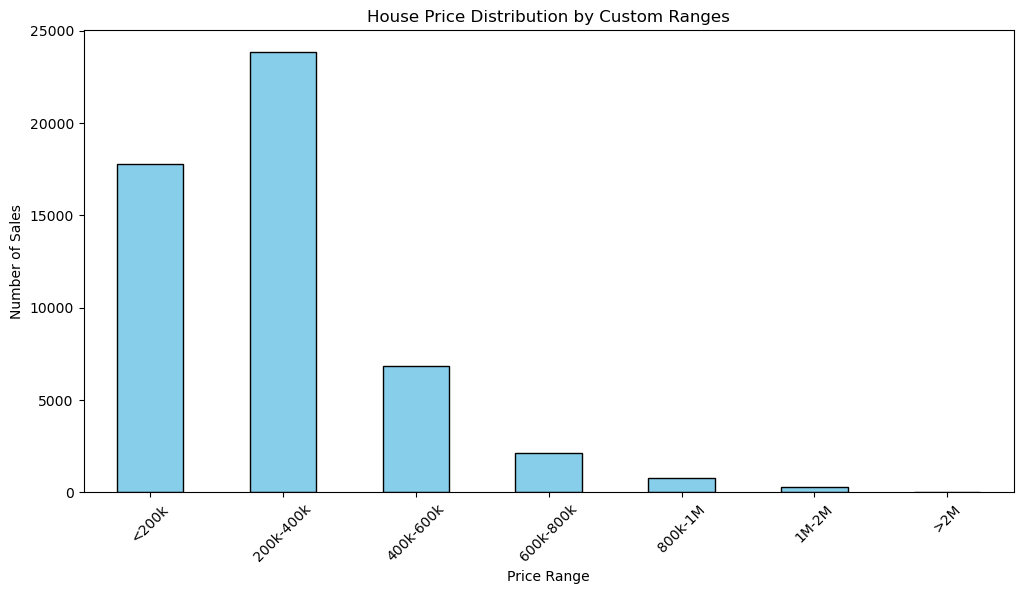

In [13]:
# detect outliers
outliers = train_df[(train_df['Price(1,000 €)'] < lower_bound) | (train_df['Price(1,000 €)'] > upper_bound)]

print(f"sample size: {len(train_df)}")
print(f"abnormal value: {len(outliers)}")

train_df = train_df[(train_df['Price(1,000 €)'] >= lower_bound) & (train_df['Price(1,000 €)'] <= upper_bound)].copy()

# binning and visualization
train_df['Price_Range'] = pd.cut(train_df['Price(1,000 €)'], bins=bins, labels=labels)
test_df['Price_Range'] = pd.cut(test_df['Price(1,000 €)'], bins=bins, labels=labels)
counts = train_df['Price_Range'].value_counts().reindex(labels) 

plt.figure(figsize=(12, 6))
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('House Price Distribution by Custom Ranges')
plt.ylabel('Number of Sales')
plt.xlabel('Price Range')
plt.xticks(rotation=45)
plt.show()

## Time Variable -- Date of Sale
- convert date variable to more meaningful feature for further modelling
- convert continuous variable into discrete variable

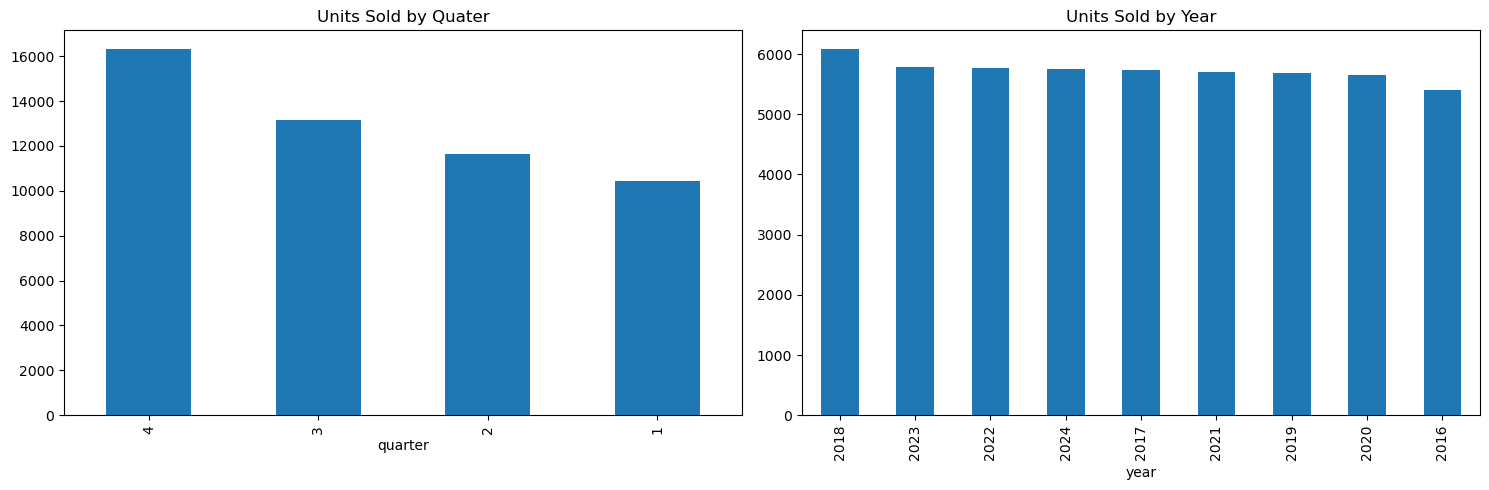

In [15]:
# Year / Month / Quarter from sale date
# -----------------------------
# TRAIN
# -----------------------------
train_df["Date of Sale"] = pd.to_datetime(
    train_df["Date of Sale (dd/mm/yyyy)"],
    format="%d/%m/%Y",
    errors="coerce"
)

train_df["year"] = train_df["Date of Sale"].dt.year
train_df["quarter"] = train_df["Date of Sale"].dt.quarter.astype("category")

train_df = train_df.drop(columns=["Date of Sale (dd/mm/yyyy)", "Date of Sale"])

# -----------------------------
# TEST
# -----------------------------
test_df["Date of Sale"] = pd.to_datetime(
    test_df["Date of Sale (dd/mm/yyyy)"],
    format="%d/%m/%Y",
    errors="coerce"
)

test_df["year"] = test_df["Date of Sale"].dt.year
test_df["quarter"] = test_df["Date of Sale"].dt.quarter.astype("category")

# normalize the year, set min as 0 and always use the minmum value in train dataset as test dataset is 2025 but train dataset is before 2025
train_df["year_norm"] = train_df["year"] - train_df["year"].min()
test_df["year_norm"] = test_df["year"] - train_df["year"].min()

test_df = test_df.drop(columns=["Date of Sale (dd/mm/yyyy)", "Date of Sale"])
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(15,5))

train_df["quarter"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Units Sold by Quater")

train_df["year"].value_counts().head(10).plot(kind="bar", ax=axes[1])
axes[1].set_title("Units Sold by Year")

plt.tight_layout()
plt.show()

## Catagorical Variables
- Description of Property
- VAT Exclusive
- Not Full Market Price
- convert into binary variable

In [17]:
print(train_df["Description of Property"].unique())
print(train_df["VAT Exclusive"].unique())
print(train_df["Not Full Market Price"].unique())

['Second-Hand Dwelling house /Apartment' 'New Dwelling house /Apartment'
 'Teach/Árasán Cónaithe Atháimhe' 'Teach/Árasán Cónaithe Nua']
['No' 'Yes']
['No' 'Yes']


In [18]:
# -----------------------------
# Convert Yes/No columns to binary (Yes=1, No=0)
# -----------------------------
yn_map = {"Yes": 1, "No": 0}
train_df["Not Full Market Price"] = train_df["Not Full Market Price"].map(yn_map).astype("Int64")
train_df["VAT Exclusive"] = train_df["VAT Exclusive"].map(yn_map).astype("Int64")
test_df["Not Full Market Price"] = test_df["Not Full Market Price"].map(yn_map).astype("Int64")
test_df["VAT Exclusive"] = test_df["VAT Exclusive"].map(yn_map).astype("Int64")

# ---------------------------------------
# Convert Description of Property to binary variable
# 1 = New property
# 0 = Second-hand property
# ---------------------------------------

# Step 1: standardize Irish and English labels
train_df["Description of Property"] = train_df["Description of Property"].replace({
    "Teach/Árasán Cónaithe Atháimhe": "Second-Hand Dwelling house /Apartment",
    "Teach/Árasán Cónaithe Nua": "New Dwelling house /Apartment"
})
test_df["Description of Property"] = test_df["Description of Property"].replace({
    "Teach/Árasán Cónaithe Atháimhe": "Second-Hand Dwelling house /Apartment",
    "Teach/Árasán Cónaithe Nua": "New Dwelling house /Apartment"
})

# Step 2: create binary variable
train_df["is_new_property"] = (
    train_df["Description of Property"] == "New Dwelling house /Apartment"
).astype(int)
test_df["is_new_property"] = (
    test_df["Description of Property"] == "New Dwelling house /Apartment"
).astype(int)

# Step 3: verify conversion
print(train_df["is_new_property"].value_counts())

# Step 4 (optional but recommended): drop original text column
train_df = train_df.drop(columns=["Description of Property"])
test_df = test_df.drop(columns=["Description of Property"])

is_new_property
0    42037
1     9553
Name: count, dtype: int64


In [19]:
train_df.head(5)
# train_df.to_csv(clean_data.csv)

,Address,County,Not Full Market Price,VAT Exclusive,lat,lng,"Price(1,000 €)",Price_Range,year,quarter,year_norm,is_new_property
0,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,0,0,53.327500,-8.21944,125.0,<200k,2016,4,0,0
1,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,0,0,54.950000,-7.73333,100.0,<200k,2016,2,0,0
2,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,1,1,53.333060,-6.24889,175.0,<200k,2016,4,0,1
3,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,0,0,53.990830,-7.36056,65.0,<200k,2016,2,0,0
4,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,0,0,53.296101,-6.49200,190.0,<200k,2016,3,0,0


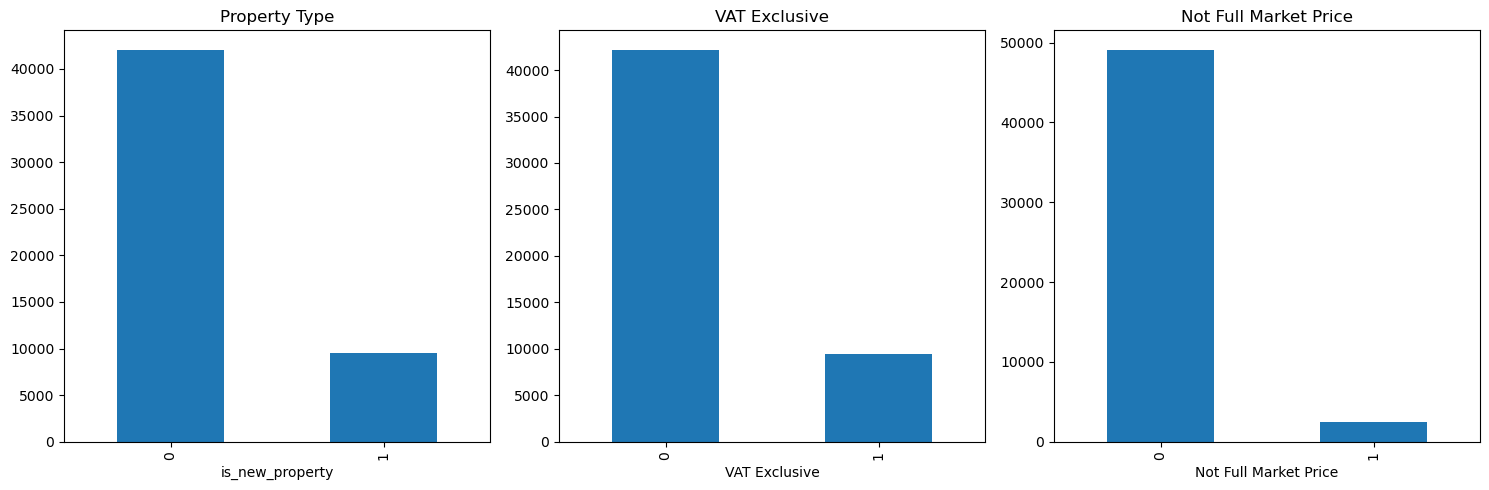

In [20]:
# distribution according to not full market price, vat exclusive and property type
fig, axes = plt.subplots(1, 3, figsize=(15,5))

train_df["is_new_property"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Property Type")

train_df["VAT Exclusive"].value_counts().head(10).plot(kind="bar", ax=axes[1])
axes[1].set_title("VAT Exclusive")

train_df["Not Full Market Price"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Not Full Market Price")

plt.tight_layout()
plt.show()

## Location Variable - Country

In [22]:
# a map to show the geographical distribution

# Featuer Pairs - Correlation analysis

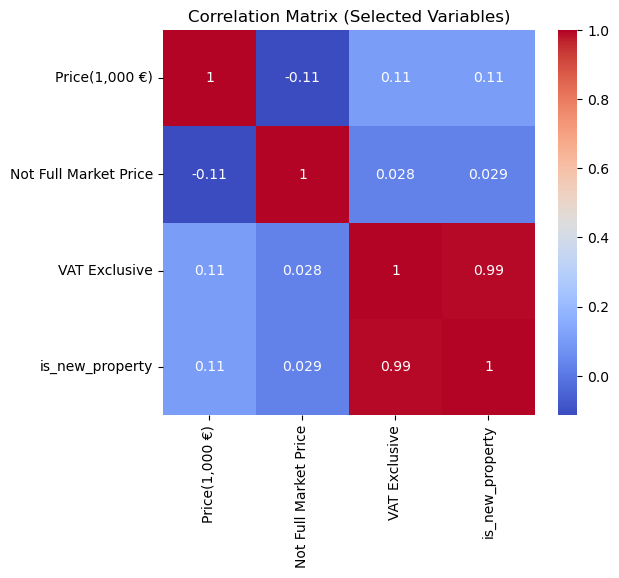

In [24]:
# Correlation Matrix
import seaborn as sns

selected_vars = ["Price(1,000 €)", "Not Full Market Price", "VAT Exclusive", "is_new_property"]

corr_matrix = train_df[selected_vars].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix (Selected Variables)")
plt.show()

C:\Users\Ja'c'k\AppData\Local\Temp\ipykernel_9644\1874401976.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby("quarter")["Price(1,000 €)"].mean().plot(kind="line", ax=axes[0,0], title="Quarter")


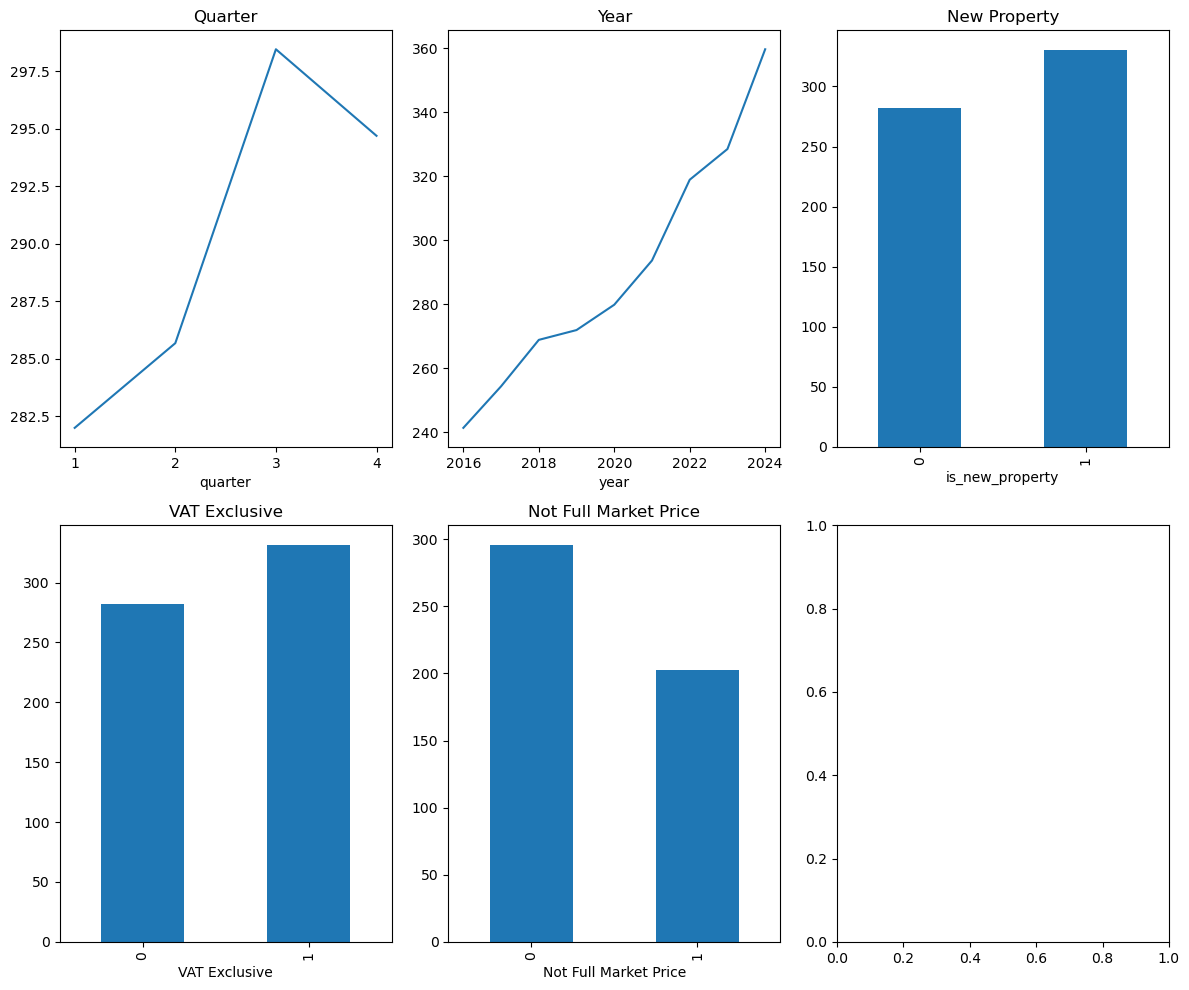

In [25]:
# average price group by quarter and binary binary variables
fig, axes = plt.subplots(2,3, figsize=(12,10))

train_df.groupby("quarter")["Price(1,000 €)"].mean().plot(kind="line", ax=axes[0,0], title="Quarter")

train_df.groupby("year")["Price(1,000 €)"].mean().plot(kind="line", ax=axes[0,1], title="Year")

train_df.groupby("is_new_property")["Price(1,000 €)"].mean().plot(kind="bar", ax=axes[0,2], title="New Property")

train_df.groupby("VAT Exclusive")["Price(1,000 €)"].mean().plot(kind="bar", ax=axes[1,0], title="VAT Exclusive")

train_df.groupby("Not Full Market Price")["Price(1,000 €)"].mean().plot(kind="bar", ax=axes[1,1], title="Not Full Market Price")

plt.tight_layout()
plt.show()

In [26]:
# map to show the average price in each country

# Create new features
- get logitude and latitude from Address
- build a dictionary to store the log and lat of economic center for each country
- calculate the distance from propert to economic center of each country

In [28]:
"""
# -----------------------------
# Load
# Due to access limit (2500 /key/day), this part of code is executed by three members in 7 days seperately
# -----------------------------

df = pd.read_csv("ppr-group-24209891-train.csv")

df = df.reset_index(drop=True)

import requests
import time
from tqdm import tqdm

API_KEY = "YOUR_API_KEY" # Your API Key go to https://opencagedata.com/ and get key; only 2500 rows per day

CSV_OUT = "your_file_name.csv" 

ADDRESS_COL = "Address"
COUNTY_COL = "County"

# Create empty columns
df["lat"] = None
df["lng"] = None

def geocode(address):
    url = "https://api.opencagedata.com/geocode/v1/json"
    params = {
        "q": address,
        "key": API_KEY,
        "countrycode": "ie",
        "limit": 1
    }
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        return None, None
    
    data = response.json()
    if data["results"]:
        lat = data["results"][0]["geometry"]["lat"]
        lng = data["results"][0]["geometry"]["lng"]
        return lat, lng
    return None, None

for i in tqdm(range(len(df))):
    address = str(df.loc[i, ADDRESS_COL]) + ", " + str(df.loc[i, COUNTY_COL]) + ", Ireland"
    
    lat, lng = geocode(address)
    
    df.loc[i, "lat"] = lat
    df.loc[i, "lng"] = lng
    
    time.sleep(1)  # IMPORTANT: avoid rate limit

df.to_csv(CSV_OUT, index=False)
"""
"""
# -----------------------------
# Load: after all longitute and latitude data available, we combine all of them into one table
# -----------------------------
import glob

files = glob.glob("path_to_data_file")

dfs = [pd.read_csv(f) for f in files]

df = pd.concat(dfs, ignore_index=True)

df.to_csv("train.csv", index=False)
"""

'\n# -----------------------------\n# Load: after all longitute and latitude data available, we combine all of them into one table\n# -----------------------------\nimport glob\n\nfiles = glob.glob("path_to_data_file")\n\ndfs = [pd.read_csv(f) for f in files]\n\ndf = pd.concat(dfs, ignore_index=True)\n\ndf.to_csv("train.csv", index=False)\n'

In [29]:
# Calculate the distance

from math import radians, sin, cos, sqrt, atan2

# =========================
# Config
# =========================

COUNTY_COL = "County"   # change if your column name differs
LAT_COL    = "lat"      # must exist in your data (from geocoding)
LNG_COL    = "lng"      # must exist in your data (from geocoding)

OUT_COL = "distance_to_local_economic_center_km"

# =========================
# County -> local economic center (approx)
# =========================
# NOTE:
# - These are practical “center city/town” coordinates for each county.
# - If your county names differ (e.g., "Co. Dublin", "Dublin City"), the normalizer below helps.
county_center = {
    "carlo": (52.8365, -6.9341),          # Carlow
    "cavan": (53.9900, -7.3600),          # Cavan
    "clare": (52.6638, -8.6267),          # Limerick (strongest nearby hub); alternative: Ennis
    "cork": (51.8985, -8.4756),           # Cork
    "donegal": (54.6540, -8.1100),        # Letterkenny-ish region
    "dublin": (53.3498, -6.2603),         # Dublin
    "galway": (53.2707, -9.0568),         # Galway
    "kerry": (52.1545, -9.5669),          # Tralee/Killarney area
    "kildare": (53.1593, -6.9099),        # Naas
    "kilkenny": (52.6541, -7.2448),       # Kilkenny
    "laois": (53.0340, -7.2990),          # Portlaoise
    "leitrim": (54.1250, -8.0000),        # Carrick-on-Shannon area
    "limerick": (52.6638, -8.6267),       # Limerick
    "longford": (53.7275, -7.7930),       # Longford
    "louth": (53.9979, -6.4023),          # Dundalk/Drogheda corridor
    "mayo": (53.8550, -9.2980),           # Castlebar/Westport area
    "meath": (53.6055, -6.6564),          # Navan
    "monaghan": (54.2492, -6.9683),       # Monaghan
    "offaly": (53.2734, -7.7783),         # Tullamore
    "roscommon": (53.7598, -8.2682),      # Roscommon
    "sligo": (54.2766, -8.4761),          # Sligo
    "tipperary": (52.4738, -8.1557),      # Thurles/Cashel area
    "waterford": (52.2593, -7.1101),      # Waterford
    "westmeath": (53.5266, -7.3386),      # Mullingar/Athlone corridor
    "wexford": (52.3369, -6.4633),        # Wexford
    "wicklow": (52.9862, -6.3675),        # Wicklow
}

# Some datasets use "Laois" as "Queen's County" historically (rare); add aliases if needed.
county_alias = {
    "co dublin": "dublin",
    "county dublin": "dublin",
    "dublin city": "dublin",
    "co cork": "cork",
    "county cork": "cork",
    "co galway": "galway",
    "county galway": "galway",
    "co limerick": "limerick",
    "county limerick": "limerick",
    "co waterford": "waterford",
    "county waterford": "waterford",
}

def normalize_county(x) -> str:
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = s.replace(".", "").replace(",", "")
    s = " ".join(s.split())
    # map aliases
    if s in county_alias:
        return county_alias[s]
    # also handle "co <name>"
    if s.startswith("co "):
        s2 = s[3:].strip()
        return county_alias.get(s, s2)
    if s.startswith("county "):
        return s[7:].strip()
    return s

# =========================
# Haversine distance (km)
# =========================
def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

def compute_distance(row) -> float | None:
    lat = row.get(LAT_COL, None)
    lng = row.get(LNG_COL, None)
    if pd.isna(lat) or pd.isna(lng):
        return None

    county_raw = row.get(COUNTY_COL, "")
    county = normalize_county(county_raw)
    if not county:
        return None

    center = county_center.get(county)
    if center is None:
        return None

    c_lat, c_lng = center
    return haversine_km(float(lat), float(lng), c_lat, c_lng)

# =========================
# Run
# =========================

# Create distance feature
train_df[OUT_COL] = train_df.apply(compute_distance, axis=1)
test_df[OUT_COL] = test_df.apply(compute_distance, axis=1)

train_df.head(5)

,Address,County,Not Full Market Price,VAT Exclusive,lat,lng,"Price(1,000 €)",Price_Range,year,quarter,year_norm,is_new_property,distance_to_local_economic_center_km
0,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,0,0,53.327500,-8.21944,125.0,<200k,2016,4,0,0,56.003110
1,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,0,0,54.950000,-7.73333,100.0,<200k,2016,2,0,0,40.818330
2,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,1,1,53.333060,-6.24889,175.0,<200k,2016,4,0,1,2.009631
3,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,0,0,53.990830,-7.36056,65.0,<200k,2016,2,0,0,0.099288
4,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,0,0,53.296101,-6.49200,190.0,<200k,2016,3,0,0,16.506682


In [30]:
train_df.isna().sum().sort_values(ascending=False)

distance_to_local_economic_center_km    1593
lat                                     1036
lng                                     1036
Address                                    0
County                                     0
Not Full Market Price                      0
VAT Exclusive                              0
Price(1,000 €)                             0
Price_Range                                0
year                                       0
quarter                                    0
year_norm                                  0
is_new_property                            0
dtype: int64

In [31]:
# drop row with missing values
train_df = train_df.dropna()
test_df = test_df.dropna()
# formating location and time variable
train_df["County"] = train_df["County"].astype(str).str.strip()
train_df["quarter"] = train_df["quarter"].astype(str).str.strip()
test_df["County"] = test_df["County"].astype(str).str.strip()
test_df["quarter"] = test_df["quarter"].astype(str).str.strip()
# rename variables for further analysis
train_df = train_df.rename(columns={
    "Price(1,000 €)": "price",
    "distance_to_local_economic_center_km": "distance",
    "Not Full Market Price": "not_full_price",
    "VAT Exclusive": "vatx",
    })
test_df = test_df.rename(columns={
    "Price(1,000 €)": "price",
    "distance_to_local_economic_center_km": "distance",
    "Not Full Market Price": "not_full_price",
    "VAT Exclusive": "vatx",
    })
# drop intermediate variables
train_df = train_df.drop(columns=["lat","lng"])
test_df = test_df.drop(columns=["lat","lng"])
# considering the right skewed distribution of price, add log price
train_df["LnP"] = np.log(train_df["price"])
test_df["LnP"] = np.log(test_df["price"])

In [32]:
train_df.describe()

,not_full_price,vatx,price,year,year_norm,is_new_property,distance,LnP
count,49997.0,49997.0,49997.000000,49997.000000,49997.000000,49997.000000,49997.000000,49997.000000
mean,0.048903,0.183391,292.399703,2020.044643,4.044643,0.185931,14.056050,5.509025
std,0.215667,0.386991,176.003272,2.575364,2.575364,0.389055,15.508672,0.594234
min,0.0,0.0,54.500000,2016.000000,0.000000,0.000000,0.037195,3.998201
25%,0.0,0.0,170.000000,2018.000000,2.000000,0.000000,2.009631,5.135798
50%,0.0,0.0,259.000000,2020.000000,4.000000,0.000000,8.652423,5.556828
75%,0.0,0.0,365.640000,2022.000000,6.000000,0.000000,22.477107,5.901649
max,1.0,1.0,1190.000000,2024.000000,8.000000,1.000000,186.702252,7.081709


# Model Evaluation

## Linear Regression - OLS with fixed effect

In [35]:
import statsmodels.formula.api as smf

model = smf.ols(
    formula="LnP ~ distance + not_full_price + vatx + is_new_property + year_norm + C(County) + C(quarter)",
    data=train_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": train_df["County"]}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    LnP   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     995.6
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           2.44e-28
Time:                        02:04:05   Log-Likelihood:                -32330.
No. Observations:               49997   AIC:                         6.473e+04
Df Residuals:                   49964   BIC:                         6.502e+04
Df Model:                          32                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  4

C:\Anaconda\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 32, but rank is 8
  warnings.warn('covariance of constraints does not have full '


In [36]:
from sklearn.metrics import r2_score, root_mean_squared_error
y_pred = model.predict(test_df)

y_true = test_df["LnP"]

r2 = r2_score(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)

print("Test R²:", r2)
print("Test RMSE:", rmse)

Test R²: 0.12544432967238706
Test RMSE: 0.6308476069233517


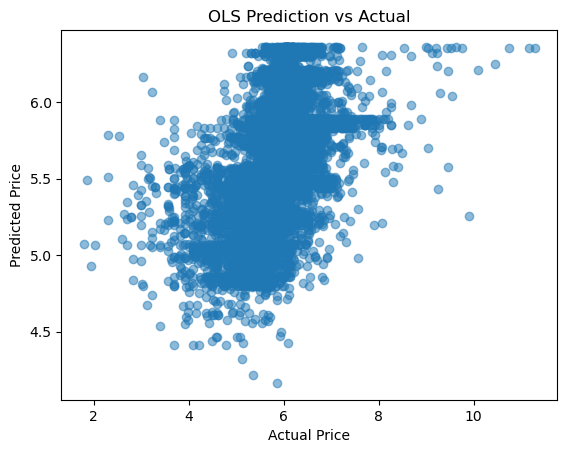

In [37]:
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("OLS Prediction vs Actual")
plt.show()

# Random Forest

In [39]:
from sklearn.ensemble import RandomForestRegressor
features = [
    "distance",
    "not_full_price",
    "vatx",
    "is_new_property",
    "County",
    "quarter",
    "year_norm"
]

X_train = pd.get_dummies(train_df[features], drop_first=True)
y_train = train_df["LnP"]

X_test = pd.get_dummies(test_df[features], drop_first=True)
y_test = test_df["LnP"]

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [40]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("OOB R²:", rf.oob_score_)

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_train, rf.oob_prediction_))
print("OOB RMSE:", rmse)

y_pred = rf.predict(X_test)

test_r2 = r2_score(y_test,y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("test R²:",test_r2)
print("test RMSE:",test_rmse)

OOB R²: 0.38059147154832496
OOB RMSE: 0.4676726185992899
test R²: 0.03706801721020514
test RMSE: 0.6619551049303541


In [41]:
importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

distance          0.320325
County_Dublin     0.243699
year_norm         0.132105
vatx              0.036430
not_full_price    0.030492
County_Wicklow    0.027001
quarter_4         0.026508
quarter_3         0.025462
quarter_2         0.024776
County_Kildare    0.021996
dtype: float64
